# Generalized Simon's Algorithm

Simon's algorithm finds a hidden binary period. Its generalized form finds a
whole subspace of periods. This notebook derives the sampling rule, implements
the quantum circuit in Qiskit, and recovers a basis of the hidden subspace
using classical binary linear algebra.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Success and cost](#cost)

Run the cells from top to bottom. The examples use an ideal local simulator.

<a id="problem"></a>
## 1. The problem

Let $G=\mathbb{F}_2^n$, with bitwise XOR as addition. We are given oracle access to
a function $f:\mathbb{F}_2^n\to\mathbb{F}_2^m$ and the promise that some subspace
$K\leq\mathbb{F}_2^n$ satisfies

$$
f(x)=f(x')\quad\Longleftrightarrow\quad x\oplus x'\in K.
$$

Thus $f$ is constant on each coset $x+K$ and takes different values on different
cosets. The function need not be linear. If $\dim K=k$, each output has
$2^k$ preimages and there are $2^{n-k}$ distinct outputs. Consequently, the
output register must have room for them, so $m\geq n-k$.

The task is to return a basis $s_1,\ldots,s_k$ such that

$$
K=\left\{a_1s_1\oplus\cdots\oplus a_ks_k:
a_1,\ldots,a_k\in\mathbb{F}_2\right\}.
$$

A basis describes every hidden period without listing all $2^k$ elements.
Different correct bases can describe the same subspace.

| Hidden dimension | Meaning |
|---|---|
| $k=0$ | $K=\{0\}$ and $f$ is one-to-one |
| $k=1$ | $K=\{0,s\}$, the nonzero-period Simon problem |
| $1<k<n$ | Several independent hidden periods |
| $k=n$ | $K=\mathbb{F}_2^n$ and $f$ is constant |

This is the binary-subspace formulation of
[generalized Simon's problem](https://arxiv.org/abs/1905.08549).
We will not require $k$ as an input. The classical section explains how
ordinary evaluations of $f$ certify that enough samples have been collected.

<a id="quantum"></a>
## 2. Quantum section

### From an oracle query to a coset state

Use the reversible XOR oracle

$$
U_f\lvert x\rangle\lvert z\rangle
=\lvert x\rangle\lvert z\oplus f(x)\rangle.
$$

Starting with two zero registers, apply a Hadamard gate to every input qubit
and then query the oracle:

$$
\lvert 0^n\rangle\lvert 0^m\rangle
\longmapsto
\frac{1}{\sqrt{2^n}}\sum_{x\in\mathbb{F}_2^n}
\lvert x\rangle\lvert 0^m\rangle
\longmapsto
\frac{1}{\sqrt{2^n}}\sum_{x\in\mathbb{F}_2^n}
\lvert x\rangle\lvert f(x)\rangle.
$$

To analyze the input register, imagine measuring the output and obtaining
$f(x_0)$. The promise says that exactly the inputs in $x_0+K$ remain.
The normalized input state is therefore

$$
\lvert x_0+K\rangle
=\frac{1}{\sqrt{|K|}}\sum_{h\in K}\lvert x_0\oplus h\rangle.
$$

The implemented circuit does not measure the output register. Ignoring it
gives the same input measurement statistics as measuring it and discarding
the result. This avoids a mid-circuit measurement.

### Why the samples are orthogonal to every hidden period

Define the binary inner product by

$$
x\cdot y=\left(\sum_{j=0}^{n-1}x_jy_j\right)\bmod 2.
$$

The Hadamard transform acts as

$$
H^{\otimes n}\lvert x\rangle
=\frac{1}{\sqrt{2^n}}\sum_{y\in\mathbb{F}_2^n}
(-1)^{x\cdot y}\lvert y\rangle.
$$

Applying it to the coset state gives

$$
H^{\otimes n}\lvert x_0+K\rangle
=\frac{1}{\sqrt{|K|\,2^n}}
\sum_{y\in\mathbb{F}_2^n}
(-1)^{x_0\cdot y}
\left(\sum_{h\in K}(-1)^{h\cdot y}\right)\lvert y\rangle.
$$

Write

$$
K^\perp=\{y\in\mathbb{F}_2^n:h\cdot y=0
\text{ for every }h\in K\}.
$$

For $y\in K^\perp$, every summand in the inner sum equals $1$.
Otherwise, choose $h_*\in K$ with $h_*\cdot y=1$. Translation by $h_*$
permutes $K$ and reverses the sign of the sum:

$$
\sum_{h\in K}(-1)^{h\cdot y}
=\sum_{h\in K}(-1)^{(h\oplus h_*)\cdot y}
=-\sum_{h\in K}(-1)^{h\cdot y}.
$$

The sum is then zero. The binary inner product is nondegenerate, so
$\dim K^\perp=n-k$. Hence measuring the input produces

$$
\Pr(Y=y)=
\begin{cases}
2^{-(n-k)},&y\in K^\perp,\\
0,&y\notin K^\perp.
\end{cases}
$$

The phase involving $x_0$ disappears when amplitudes are squared, so this
distribution is the same for every output coset. Each run supplies a uniformly
random linear constraint on all hidden periods. It does not directly supply
a hidden period.

### Qiskit setup and bit order

Install the packages in <code>requirements.txt</code> in your notebook
environment. The optional cell below can be uncommented if needed.

We write bit strings as $x_{n-1}\cdots x_0$. Qiskit qubit $0$ corresponds to
the rightmost bit. All classical matrices below use the displayed
left-to-right string order. Only the mapping from string positions to qubits
is reversed, as described in
[Qiskit's bit-ordering guide](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import Counter
from functools import lru_cache

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


### A runnable oracle

For an explicit circuit, choose a binary matrix $A$ with $n$ columns and
define $f_A(x)=Ax$, with arithmetic modulo $2$. Then

$$
f_A(x)=f_A(x')
\quad\Longleftrightarrow\quad
A(x\oplus x')=0,
$$

so this oracle hides $K=\ker A$. Each $1$ in $A$ becomes a CNOT from an input
qubit to an output qubit. Keeping the input register makes the oracle
reversible even when $A$ is not invertible.

The matrix is used only to build the demonstration oracle. The recovery
routine receives the oracle and register sizes, without being given $A$ or
a basis of $K$. This linear family is easy to learn classically from basis-vector
queries. It illustrates the algorithm's operations, rather than providing
a classical hardness benchmark.

The implementation uses $m\geq1$. A constant function can be represented by
one zero output bit.

In [3]:
def make_linear_oracle(rows, n):
    '''Construct |x>|z> -> |x>|z XOR A x> from binary row strings.'''
    if not isinstance(n, int) or n < 1:
        raise ValueError("n must be a positive integer.")
    rows = list(rows)
    if not rows:
        raise ValueError("Supply at least one output row.")
    if any(not isinstance(row, str) or len(row) != n
           or set(row) - {"0", "1"} for row in rows):
        raise ValueError("Every row must be an n-bit binary string.")

    m = len(rows)
    circuit = QuantumCircuit(n + m, name="U_f")
    for output_position, row in enumerate(rows):
        output_qubit = n + m - 1 - output_position
        for input_position, bit in enumerate(row):
            if bit == "1":
                circuit.cx(n - 1 - input_position, output_qubit)
    return circuit.to_gate(label="U_f")


def check_oracle_size(oracle, n, m):
    if not isinstance(n, int) or not isinstance(m, int) or min(n, m) < 1:
        raise ValueError("Register sizes must be positive integers.")
    if oracle.num_qubits != n + m:
        raise ValueError("The oracle must act on exactly n + m qubits.")

### Quantum sampling implementation

Each shot prepares the zero state, applies the two Hadamard layers around
one oracle query, and measures only the input register. The figure produced
below shows this circuit.

The same <code>StatevectorSampler</code> is reused across batches with a
NumPy random generator, so successive calls advance the random state.
The simulator API returns the measurements of register <code>y</code> as
[bit strings](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).

In [4]:
def generalized_simon_circuit(oracle, n, m):
    check_oracle_size(oracle, n, m)
    x = QuantumRegister(n, "x")
    z = QuantumRegister(m, "z")
    y = ClassicalRegister(n, "y")
    circuit = QuantumCircuit(x, z, y)
    circuit.h(x)
    circuit.append(oracle, list(x) + list(z))
    circuit.h(x)
    circuit.measure(x, y)
    return circuit


def sample_orthogonal(oracle, n, m, shots, sampler):
    if not isinstance(shots, int) or shots < 1:
        raise ValueError("shots must be a positive integer.")
    circuit = generalized_simon_circuit(oracle, n, m)
    result = sampler.run([circuit], shots=shots).result()[0]
    return result.data.y.get_bitstrings()


def evaluate_oracle(oracle, n, m, bitstring, sampler):
    '''Evaluate f on one classical input using the same XOR oracle.'''
    check_oracle_size(oracle, n, m)
    if (not isinstance(bitstring, str) or len(bitstring) != n
            or set(bitstring) - {"0", "1"}):
        raise ValueError("The input must be an n-bit binary string.")
    x = QuantumRegister(n, "x")
    z = QuantumRegister(m, "z")
    value = ClassicalRegister(m, "value")
    circuit = QuantumCircuit(x, z, value)
    for position, bit in enumerate(bitstring):
        if bit == "1":
            circuit.x(x[n - 1 - position])
    circuit.append(oracle, list(x) + list(z))
    circuit.measure(z, value)
    result = sampler.run([circuit], shots=1).result()[0]
    return result.data.value.get_bitstrings()[0]

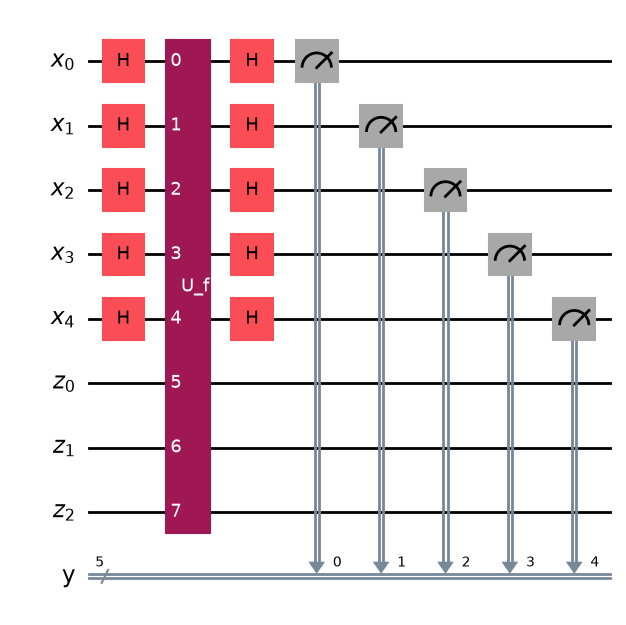

In [5]:
n = 5
oracle_rows = ["10100", "01010", "00101"]
m = len(oracle_rows)
oracle = make_linear_oracle(oracle_rows, n)
sampler = StatevectorSampler(seed=np.random.default_rng(2026))

display(generalized_simon_circuit(oracle, n, m).draw("mpl", fold=-1))

Number of samples: 24
Observed outcomes: {'00000': 1, '00101': 3, '01010': 5, '01111': 3, '10001': 2, '10100': 4, '11011': 3, '11110': 3}


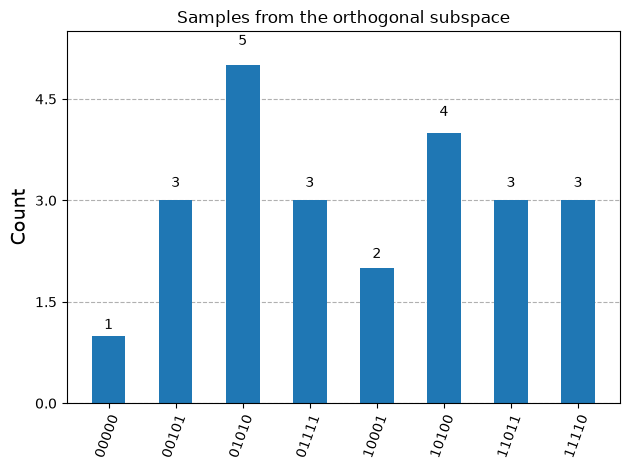

In [6]:
samples = sample_orthogonal(oracle, n, m, shots=24, sampler=sampler)
counts = Counter(samples)
print("Number of samples:", len(samples))
print("Observed outcomes:", dict(sorted(counts.items())))
display(plot_histogram(dict(sorted(counts.items())), title="Samples from the orthogonal subspace"))

<a id="classical"></a>
## 3. Classical section

### Recover a basis by solving binary equations

Place the sampled strings into the rows of a matrix $Y$. Every hidden period
$s\in K$ satisfies

$$
Ys=0\pmod 2.
$$

If $W$ is the row span of $Y$, then the candidate subspace is

$$
L=\ker Y=W^\perp.
$$

All samples belong to $K^\perp$, so $W\subseteq K^\perp$ and therefore
$K\subseteq L$. When the rows span all of $K^\perp$, their rank is $n-k$.
Then $\dim L=k$ and $L=K$. Too few independent samples give a larger
candidate subspace.

Use Gaussian elimination over $\mathbb{F}_2$. Row addition is XOR and a
nonzero pivot already equals $1$, so no division is required. For each free
column, set its variable to $1$ and the other free variables to $0$.
The reduced equations determine the pivot variables. These solutions form
a basis of the nullspace.

Real-valued rank and nullspace routines solve a different linear-algebra
problem. The implementation below uses exact binary arithmetic.

In [7]:
def nullspace_gf2(bitstrings, n):
    '''Return a nullspace basis, reduced row matrix, and pivot columns.'''
    if not isinstance(n, int) or n < 1:
        raise ValueError("n must be a positive integer.")
    bitstrings = list(bitstrings)
    if any(not isinstance(row, str) or len(row) != n
           or set(row) - {"0", "1"} for row in bitstrings):
        raise ValueError("Every row must be an n-bit binary string.")

    reduced = np.array(
        [[int(bit) for bit in row] for row in bitstrings], dtype=np.uint8
    ).reshape(len(bitstrings), n)
    pivots = []
    pivot_row = 0
    for column in range(n):
        candidates = np.flatnonzero(reduced[pivot_row:, column])
        if candidates.size == 0:
            continue
        selected = pivot_row + int(candidates[0])
        reduced[[pivot_row, selected]] = reduced[[selected, pivot_row]]
        for row in range(len(reduced)):
            if row != pivot_row and reduced[row, column]:
                reduced[row] ^= reduced[pivot_row]
        pivots.append(column)
        pivot_row += 1
        if pivot_row == len(reduced):
            break

    free_columns = [column for column in range(n) if column not in pivots]
    basis = np.zeros((len(free_columns), n), dtype=np.uint8)
    for index, free in enumerate(free_columns):
        basis[index, free] = 1
        for row, pivot in enumerate(pivots):
            basis[index, pivot] = reduced[row, free]
    return basis, reduced, pivots


def as_bitstrings(vectors):
    return ["".join(str(int(bit)) for bit in vector) for vector in vectors]

In [8]:
candidate_basis, reduced, pivots = nullspace_gf2(samples, n)
print("Sample rank:", len(pivots))
print("Nonzero rows after elimination:")
print(reduced[:len(pivots)])
print("Candidate basis:", as_bitstrings(candidate_basis))

Sample rank: 3
Nonzero rows after elimination:
[[1 0 0 0 1]
 [0 1 0 1 0]
 [0 0 1 0 1]]
Candidate basis: ['01010', '10101']


### Certify completion without knowing the hidden dimension

A rank that stops increasing for a few shots does not prove that the samples
are complete. Instead, the oracle promise gives an exact membership test:

$$
v\in K\quad\Longleftrightarrow\quad f(v)=f(0).
$$

Let $v_1,\ldots,v_\ell$ be the computed basis of $L=\ker Y$.
If every basis vector passes this test, all of their binary combinations
belong to $K$, since $K$ is a subspace. Thus $L\subseteq K$.
Together with $K\subseteq L$, this proves $L=K$.

If any basis vector fails, gather more quantum samples. At most $\ell+1$
ordinary function evaluations are needed for one check, including $f(0)$.
An empty basis means $L=\{0\}$, so $K=\{0\}$ without further queries.

If $k$ is supplied as part of the promise, reaching rank $n-k$ is an
alternative stopping criterion. The implementation below uses the
membership checks so that it also works when $k$ is unknown.

The classical decision uses only function values. The helper
<code>evaluate_oracle</code> realizes each ordinary evaluation through a
computational-basis circuit, whose ideal output is deterministic.

In [9]:
def certify_hidden_subgroup(bitstrings, n, evaluate_f):
    '''Return (basis, rank) if certified, otherwise (None, rank).'''
    basis, _, pivots = nullspace_gf2(bitstrings, n)
    if len(basis) == 0:
        return [], len(pivots)
    zero_value = evaluate_f("0" * n)
    basis_strings = as_bitstrings(basis)
    for vector in basis_strings:
        if evaluate_f(vector) != zero_value:
            return None, len(pivots)
    return basis_strings, len(pivots)


def recover_generalized_simon(
    oracle, n, m, *, batch_size=12, max_batches=6, seed=2026
):
    '''Recover and certify a basis of K, or report the sample limit.'''
    check_oracle_size(oracle, n, m)
    if (not isinstance(batch_size, int) or batch_size < 1
            or not isinstance(max_batches, int) or max_batches < 1):
        raise ValueError("Batch sizes and limits must be positive integers.")

    sampler = StatevectorSampler(seed=np.random.default_rng(seed))
    function_queries = 0

    @lru_cache(maxsize=None)
    def evaluate_f(bitstring):
        nonlocal function_queries
        function_queries += 1
        return evaluate_oracle(oracle, n, m, bitstring, sampler)

    all_samples = []
    for batch in range(1, max_batches + 1):
        all_samples.extend(
            sample_orthogonal(oracle, n, m, batch_size, sampler)
        )
        basis, rank = certify_hidden_subgroup(all_samples, n, evaluate_f)
        if basis is not None:
            return {
                "basis": basis,
                "dimension": len(basis),
                "sample_rank": rank,
                "sample_count": len(all_samples),
                "verification_queries": function_queries,
                "batches": batch,
            }

    raise RuntimeError(
        f"Could not certify the subgroup within {len(all_samples)} samples. "
        "Increase max_batches for another bounded attempt."
    )

### Run the complete algorithm

This call supplies only the oracle and register sizes. It returns generators
of the hidden subgroup, the recovered dimension, and the number of queries.
Repeated function evaluations are cached.

In [10]:
result = recover_generalized_simon(oracle, n, m)
for key, value in result.items():
    print(f"{key}: {value}")

assert result["dimension"] + result["sample_rank"] == n
assert result["dimension"] == 2
print("The two returned generators describe a subgroup of size", 2 ** result["dimension"])

basis: ['01010', '10101']
dimension: 2
sample_rank: 3
sample_count: 12
verification_queries: 3
batches: 1
The two returned generators describe a subgroup of size 4


### Insufficient data and limiting cases

With no constraints, the candidate nullspace is the whole input space.
For the nonconstant demonstration oracle, certification rejects this candidate.

The next cells also cover an injective function, the ordinary one-period
case, and a constant function. The trivial subgroup is represented by an
empty list of generators. The constant case returns a basis of the full
space. All decisions still use the same recovery routine.

In [11]:
check_sampler = StatevectorSampler(seed=np.random.default_rng(17))
basis, rank = certify_hidden_subgroup(
    [], n, lambda x: evaluate_oracle(oracle, n, m, x, check_sampler)
)
assert basis is None and rank == 0
print("No samples: the candidate was rejected, so more samples are needed.")

No samples: the candidate was rejected, so more samples are needed.


In [12]:
cases = [
    ("Injective", ["100", "010", "001"], 0),
    ("One hidden period", ["101", "011"], 1),
    ("Constant", ["000"], 3),
]
for label, rows, expected_dimension in cases:
    test_oracle = make_linear_oracle(rows, 3)
    recovered = recover_generalized_simon(test_oracle, 3, len(rows), seed=41)
    assert recovered["dimension"] == expected_dimension
    print(f"{label}: basis={recovered['basis']}, dimension={recovered['dimension']}")

Injective: basis=[], dimension=0
One hidden period: basis=['111'], dimension=1
Constant: basis=['100', '010', '001'], dimension=3


<a id="cost"></a>
## 4. Success probability and computational cost

Put $d=n-k=\dim K^\perp$. After $t$ independent uniform samples, failure
to span $K^\perp$ means that some nonzero linear functional on this
$d$-dimensional space vanishes on every sample. There are $2^d-1$ such
functionals, and each vanishes on one uniform sample with probability $1/2$.
The union bound gives

$$
\Pr(\operatorname{rank}Y<d)\leq(2^d-1)2^{-t}<2^{d-t}
\qquad(d>0).
$$

Therefore $t\geq d+\lceil\log_2(1/\delta)\rceil$ suffices for failure probability
below $\delta$, where $0<\delta<1$. Without knowing $k$, one may conservatively
replace $d$ by $n$. If $d=0$, every sample is zero and the candidate full
space can be certified immediately.

Under the oracle promise and ideal sampling, a returned answer is correct.
The bounded loop may instead report that it could not certify an answer.
It never substitutes an uncertified candidate. This is a randomized sampling
implementation with verification, not an implementation of the
amplitude-amplification algorithms that guarantee a fixed query bound.

For one batch collection totaling $t$ samples:

- Quantum sampling uses $t$ oracle calls, $2nt$ Hadamard gates, and $nt$ input
  measurements.
- The displayed binary elimination and basis construction use
  $O(tn^2+n^2)$ binary operations and $O(tn+n^2)$ storage.
- A certification checks at most $n$ candidate generators, plus $f(0)$.
  Comparing a pair of output strings costs $O(m)$.

The supplied loop recomputes elimination after each batch. If it takes $B$
batches and $t$ total samples, its elimination work is at most
$O(Btn^2+Bn^2)$. Let $q$ be the number of distinct ordinary evaluations
actually made. Caching gives $q\leq Bn+1$ and adds
$O(q(n+m))$ storage. The function-evaluation costs are separate from
these binary-operation counts.

If a realization of $U_f$ costs $C_f$ elementary gates, sampling and
verification together use

$$
O\!\left((t+q)(C_f+n+m)\right)
$$

gates and measured bits, with register initialization included in this upper
bound. The demonstration oracle has at most $mn$ CNOT gates.

These are costs for a quantum implementation. The statevector simulator
stores $O(2^{n+m})$ complex amplitudes. Keep the demonstration registers
small. The exact equations and certification argument also assume ideal
measurements. Noisy samples can invalidate $K\subseteq\ker Y$, so this
notebook is not a noise-tolerant recovery method.

## References

- Zhenggang Wu, Daowen Qiu, Jiawei Tan, Hao Li, and Guangya Cai,
  [Quantum and Classical Query Complexities for Generalized Simon's Problem](https://arxiv.org/abs/1905.08549).
  The problem formulation and more advanced query-complexity results.
- Andrew M. Childs and Wim van Dam,
  [Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380).
  The broader finite abelian hidden subgroup framework.
- IBM Quantum,
  [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler)
  and [bit ordering](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

Return to [Finite Abelian Hidden Subgroups Problems](../README.md).